# 05: Transfer Learning — WLASL → KSL (Fast Version)
**Group 11 · COSE474 Deep Learning · Korea University · Spring 2026**

## Overview

Fast version — uses pre-extracted VGG16 features instead of raw frames.
VGG16 forward pass is skipped entirely during training.

**Speed comparison:**
- Slow version (raw frames): ~60 min/epoch
- This version (pre-extracted features): ~30 sec/epoch

**Pipeline:**
```
~/wlasl/features/{vid_id}.pt  →  LSTM pretrain (100 classes, 40 epochs)
                                          ↓
                             Swap classifier head (100 → 67)
                                          ↓
                  KSL fine-tune: warmup (10 ep) → full (30 ep)
```

**Note:** KSL fine-tune still uses full LRCN (VGG+LSTM) since KSL frames are pre-extracted JPEGs — fast enough already.

**Compare against:**
- CNN baseline (nb02): 13.57%
- LRCN baseline (nb03): 14.34%
- MS-ASL TL v1: 10.08%
- MS-ASL TL v2: 5.43%

# Imports & Config

In [1]:
import os, json, random, csv, gc
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader

torch.cuda.empty_cache()
gc.collect()

# ── Seeds ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# ── Hyperparameters ─────────────────────────────────────────────────
NUM_FRAMES      = 32
IMG_SIZE        = 224
BATCH           = 16    # can use larger batch now — no VGG in loop
LSTM_HIDDEN     = 64
LSTM_LAYERS     = 1
DROPOUT         = 0.4
FEATURE_DIM     = 512

PRETRAIN_CLS    = 100
KSL_CLS         = 67   # updated dynamically below

PRETRAIN_EPOCHS = 40
WARMUP_EPOCHS   = 10
FINETUNE_EPOCHS = 30
PATIENCE        = 8

LR_PRETRAIN     = 5e-4
LR_HEAD         = 5e-4
LR_LSTM         = 1e-4
LR_BACKBONE     = 1e-5

NORMALIZE_MEAN  = [0.485, 0.456, 0.406]
NORMALIZE_STD   = [0.229, 0.224, 0.225]

# ── Paths ───────────────────────────────────────────────────────────
BASE_DIR      = Path('.')
FRAMES_DIR    = BASE_DIR / 'frames'              # KSL pre-extracted frames
WLASL_JSON    = Path.home() / 'wlasl' / 'nslt_100.json'
WLASL_FEATS   = Path.home() / 'wlasl' / 'features'  # pre-extracted VGG features
CKPT_DIR      = BASE_DIR / 'models' / 'checkpoints'
FIGS_DIR      = BASE_DIR / 'results' / 'figures'
LOGS_DIR      = BASE_DIR / 'results' / 'logs'
for d in [CKPT_DIR, FIGS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CKPT_PRETRAIN = str(CKPT_DIR / 'lstm_wlasl_pretrained.pth')
CKPT_FINETUNE = str(CKPT_DIR / 'lrcn_transfer_ksl_wlasl_fast.pth')

# Verify features exist
n_feats = len(list(WLASL_FEATS.glob('*.pt')))
print(f'WLASL feature files : {n_feats}')
print(f'KSL frames dir      : {FRAMES_DIR}')

Device : cuda
GPU    : NVIDIA A100 80GB PCIe MIG 2g.20gb
WLASL feature files : 1013
KSL frames dir      : frames


# KSL Word Labels

In [2]:
KSL_WORDS = {
     1:'hi',          2:'what',         3:'meat',         4:'bi bim rice',
     5:'glad',        6:'hobby',        7:'me',           8:'movie',
     9:'face',       10:'see',         11:'name',        12:'read',
    13:'thank',      14:'equal',       15:'sorry',       16:'eat',
    17:'fine',       18:'do effort',   19:'next',        20:'age',
    21:'again',      22:'how many',    23:'day',         24:'good, nice',
    25:'when',       26:'we',          27:'subway',      28:'be friendly',
    29:'bus',        30:'ride',        31:'cell phone',  32:'where',
    33:'number',     34:'location',    35:'guide',       36:'responsibility',
    37:'who',        38:'arrive',      39:'family',      40:'time',
    41:'friend',     42:'help',        43:'know',        44:'work',
    45:'parents',    46:'10 minutes',  47:'walk',        48:'feel',
    49:'think',      50:'money',       51:'teach',       52:'meet',
    53:'education',  54:'want',        55:'rest',        56:'talk',
    57:'hospital',   58:'go',          59:'house',       60:'school',
    61:'like',       62:'bad',         63:'together',    64:'because',
    65:'no',         66:'now',         67:'different',   68:'tired',
    69:'yes',        70:'do',          71:'strange',     72:'difficult',
    73:'visit',      74:'need',        75:'far',         76:'person',
    77:'much',
}
print(f'KSL words loaded: {len(KSL_WORDS)}')

KSL words loaded: 77


# Datasets

In [3]:
# ── WLASL Feature Dataset (loads .pt files — no VGG needed) ─────────
class WLASLFeatureDataset(Dataset):
    """
    Loads pre-extracted VGG16 features from ~/wlasl/features/{vid_id}.pt
    Each .pt file is shape (32, 512) — 32 frames, 512-dim feature per frame.
    Training only needs LSTM — VGG is skipped entirely.
    """
    def __init__(self, json_path, feats_dir, subset='train'):
        self.feats_dir = Path(feats_dir)

        with open(json_path, 'r') as f:
            data = json.load(f)

        self.samples = []
        for vid_id, info in data.items():
            if info['subset'] != subset:
                continue
            feat_path = self.feats_dir / f'{vid_id}.pt'
            if not feat_path.exists():
                continue
            label = info['action'][0]   # 0-indexed class id
            self.samples.append((str(feat_path), label))

        n_cls = len(set(s[1] for s in self.samples))
        print(f'[WLASL {subset}] {len(self.samples)} samples, {n_cls} classes')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feat_path, label = self.samples[idx]
        features = torch.load(feat_path, weights_only=True)  # (32, 512)
        return features, label


# ── KSL Dataset (pre-extracted frames, identical to nb03) ────────────
class KSLDataset(Dataset):
    def __init__(self, clip_dirs, transform=None,
                 label_map=None, num_frames=NUM_FRAMES):
        self.clips      = clip_dirs
        self.transform  = transform
        self.label_map  = label_map
        self.num_frames = num_frames

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip_path   = self.clips[idx]
        folder_name = os.path.basename(clip_path)
        class_id    = int(folder_name.split('_')[1])
        label       = self.label_map[class_id] \
                      if self.label_map is not None else class_id - 1
        frame_files = sorted(os.listdir(clip_path))
        if len(frame_files) < self.num_frames:
            frame_files += [frame_files[-1]] * \
                           (self.num_frames - len(frame_files))
        frame_files = frame_files[:self.num_frames]
        tensors = []
        for fname in frame_files:
            img = Image.open(os.path.join(clip_path, fname)).convert('RGB')
            if self.transform:
                img = self.transform(img)
            tensors.append(img)
        return torch.stack(tensors), label

# KSL Label Map & Train/Val Split

In [4]:
TRAIN_SIGNERS = {f'{i:02d}' for i in range(16)}
VAL_SIGNERS   = {f'{i:02d}' for i in range(16, 20)}

all_clips = sorted([
    str(FRAMES_DIR / d)
    for d in os.listdir(FRAMES_DIR)
    if (FRAMES_DIR / d).is_dir()
])

present_class_ids  = sorted({int(os.path.basename(c).split('_')[1])
                              for c in all_clips})
missing_class_ids  = sorted(set(KSL_WORDS.keys()) - set(present_class_ids))
LABEL_MAP          = {cid: i for i, cid in enumerate(present_class_ids)}
KSL_CLS            = len(present_class_ids)
INDEX_TO_WORD      = [KSL_WORDS[cid] for cid in present_class_ids]

train_clips = [c for c in all_clips
               if os.path.basename(c).split('_')[0] in TRAIN_SIGNERS]
val_clips   = [c for c in all_clips
               if os.path.basename(c).split('_')[0] in VAL_SIGNERS]

print(f'Total clips        : {len(all_clips)}')
print(f'Classes present    : {KSL_CLS}')
print(f'Missing class IDs  : {missing_class_ids}')
print(f'Train clips        : {len(train_clips)}  (signers 00-15)')
print(f'Val clips          : {len(val_clips)}   (signers 16-19)')

Total clips        : 1229
Classes present    : 67
Missing class IDs  : [12, 19, 28, 33, 35, 45, 46, 53, 73, 75]
Train clips        : 971  (signers 00-15)
Val clips          : 258   (signers 16-19)


# Models

In [5]:
# ── LSTM-only model for WLASL pretrain (takes pre-extracted features) ─
class LSTMClassifier(nn.Module):
    """
    Lightweight LSTM classifier that takes pre-extracted VGG16 features.
    Input: (B, T, 512) — no VGG forward pass needed.
    Used for WLASL pretraining only.
    """
    def __init__(self, num_classes,
                 input_dim   = FEATURE_DIM,
                 lstm_hidden = LSTM_HIDDEN,
                 lstm_layers = LSTM_LAYERS,
                 dropout     = DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_dim,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes),
        )

    def forward(self, x):
        # x: (B, T, 512)
        _, (h, _) = self.lstm(x)
        return self.classifier(h[-1])


# ── Full LRCN for KSL fine-tune (VGG + LSTM) ────────────────────────
class LRCN(nn.Module):
    """
    Full LRCN identical to nb03.
    Used for KSL fine-tuning — loads LSTM weights from pretrain.
    """
    def __init__(self, num_classes,
                 feature_dim = FEATURE_DIM,
                 lstm_hidden = LSTM_HIDDEN,
                 lstm_layers = LSTM_LAYERS,
                 dropout     = DROPOUT):
        super().__init__()
        vgg           = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = vgg.features
        self.avgpool  = vgg.avgpool

        for p in self.features.parameters():
            p.requires_grad = False

        self.frame_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size  = feature_dim,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        x = self.features(x)
        x = self.avgpool(x)
        x = self.frame_fc(x)
        x = x.view(B, T, -1)
        _, (h, _) = self.lstm(x)
        return self.classifier(h[-1])

print('Models defined')

Models defined


# Train/Val Helpers

In [6]:
def run_epoch(model, loader, optimizer, criterion, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for frames, labels in loader:
            frames  = frames.float().to(DEVICE)
            labels  = labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            outputs = model(frames)
            loss    = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total


def save_log(log_path, rows):
    with open(log_path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['epoch','tr_loss','tr_acc','vl_loss','vl_acc'])
        w.writerows(rows)
    print(f'Log saved: {log_path}')


def plot_curves(log, title, save_path):
    epochs  = [r[0] for r in log]
    tr_acc  = [r[2] for r in log]
    vl_acc  = [r[4] for r in log]
    tr_loss = [r[1] for r in log]
    vl_loss = [r[3] for r in log]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, tr_loss, label='Train')
    ax1.plot(epochs, vl_loss, label='Val')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.plot(epochs, tr_acc, label='Train')
    ax2.plot(epochs, vl_acc, label='Val')
    ax2.axhline(0.1434, color='gray',   linestyle='--', label='LRCN 14.34%')
    ax2.axhline(0.1357, color='red',    linestyle='--', label='CNN 13.57%')
    ax2.axhline(0.0543, color='orange', linestyle='--', label='MS-ASL TL 5.43%')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch'); ax2.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Figure saved: {save_path}')

print('Helpers ready')

Helpers ready


# Phase 1 — Pretrain LSTM on WLASL features

  PHASE 1: PRETRAIN LSTM ON WLASL FEATURES (100 classes)
[WLASL train] 748 samples, 100 classes
[WLASL val] 165 samples, 89 classes


/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. Thi

Ep 001 | train 0.67% loss 4.612 | val 3.64% loss 4.572 ✓


/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. Thi

/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. Thi

...

/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. Thi

Ep 035 | train 64.44% loss 1.978 | val 13.33% loss 4.300


/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. Thi

/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/elicer/.local/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. Thi

Ep 040 | train 69.39% loss 1.839 | val 12.12% loss 4.312
Log saved: results/logs/05_pretrain_wlasl_log.csv


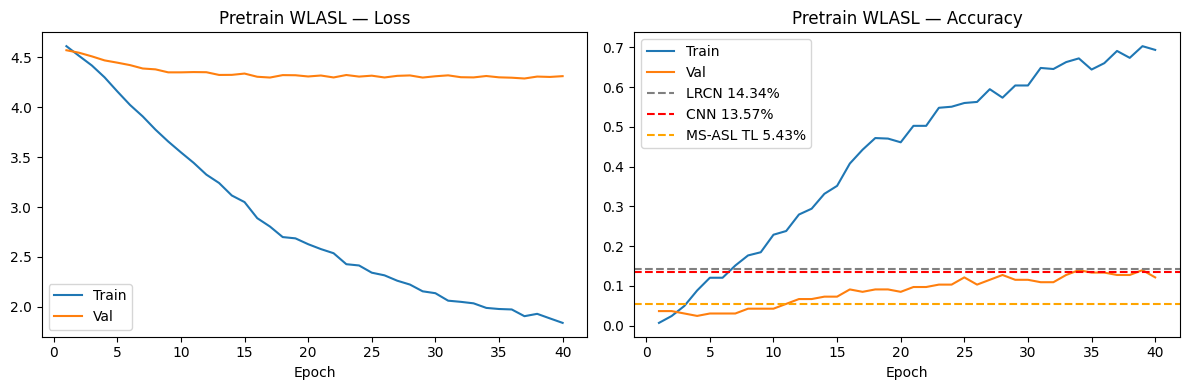

Figure saved: results/figures/05_pretrain_curves.png

Best WLASL pretrain val acc : 13.94%


In [7]:
torch.cuda.empty_cache()
gc.collect()

print('='*60)
print('  PHASE 1: PRETRAIN LSTM ON WLASL FEATURES (100 classes)')
print('='*60)

wlasl_train = WLASLFeatureDataset(WLASL_JSON, WLASL_FEATS, 'train')
wlasl_val   = WLASLFeatureDataset(WLASL_JSON, WLASL_FEATS, 'val')

wlasl_train_loader = DataLoader(wlasl_train, batch_size=BATCH,
                                 shuffle=True,  num_workers=4, pin_memory=True)
wlasl_val_loader   = DataLoader(wlasl_val,   batch_size=BATCH,
                                 shuffle=False, num_workers=4, pin_memory=True)

# LSTM-only model for pretrain
lstm_model = LSTMClassifier(num_classes=PRETRAIN_CLS).to(DEVICE)
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(
    lstm_model.parameters(),
    lr=LR_PRETRAIN, weight_decay=1e-4
)
scheduler  = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=15, gamma=0.5)

best_pretrain_acc = 0
pretrain_log      = []

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(lstm_model, wlasl_train_loader,
                                optimizer, criterion, training=True)
    vl_loss, vl_acc = run_epoch(lstm_model, wlasl_val_loader,
                                optimizer, criterion, training=False)
    scheduler.step()
    pretrain_log.append([epoch, tr_loss, tr_acc, vl_loss, vl_acc])

    if vl_acc > best_pretrain_acc:
        best_pretrain_acc = vl_acc
        torch.save(lstm_model.state_dict(), CKPT_PRETRAIN)
        marker = ' ✓'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:03d} | '
              f'train {tr_acc:.2%} loss {tr_loss:.3f} | '
              f'val {vl_acc:.2%} loss {vl_loss:.3f}{marker}')

save_log(str(LOGS_DIR / '05_pretrain_wlasl_log.csv'), pretrain_log)
plot_curves(pretrain_log, 'Pretrain WLASL',
            str(FIGS_DIR / '05_pretrain_curves.png'))
print(f'\nBest WLASL pretrain val acc : {best_pretrain_acc:.2%}')

# Phase 2 — Fine-tune on KSL (67 classes)

In [8]:
print('='*60)
print('  PHASE 2: FINE-TUNE ON KSL (67 classes)')
print('='*60)

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

ksl_train_ds = KSLDataset(train_clips, base_transform, LABEL_MAP)
ksl_val_ds   = KSLDataset(val_clips,   base_transform, LABEL_MAP)

ksl_train_loader = DataLoader(ksl_train_ds, batch_size=8,
                               shuffle=True,  num_workers=4, pin_memory=True)
ksl_val_loader   = DataLoader(ksl_val_ds,   batch_size=8,
                               shuffle=False, num_workers=4, pin_memory=True)

print(f'KSL train : {len(ksl_train_ds)} | val : {len(ksl_val_ds)}')

# Build full LRCN and load pretrained LSTM weights
lrcn_model = LRCN(num_classes=KSL_CLS).to(DEVICE)

# Load only LSTM + classifier weights from pretrain
pretrain_state = torch.load(CKPT_PRETRAIN, map_location=DEVICE)

# Map LSTMClassifier weights → LRCN weights
lrcn_state = lrcn_model.state_dict()
for key, val in pretrain_state.items():
    if key.startswith('lstm.'):
        lrcn_state[key] = val
        print(f'  Loaded: {key}')
lrcn_model.load_state_dict(lrcn_state)

# Classifier head stays random (100 → 67 already handled by LRCN init)
print(f'\nLSTM weights transferred from WLASL pretrain ✓')

  PHASE 2: FINE-TUNE ON KSL (67 classes)
KSL train : 971 | val : 258
  Loaded: lstm.weight_ih_l0
  Loaded: lstm.weight_hh_l0
  Loaded: lstm.bias_ih_l0
  Loaded: lstm.bias_hh_l0

LSTM weights transferred from WLASL pretrain ✓


In [9]:
# ── Warmup: head + LSTM only ─────────────────────────────────────────
print(f'\n-- Warmup ({WARMUP_EPOCHS} epochs): head + LSTM only --')

optimizer_warmup = torch.optim.Adam([
    {'params': lrcn_model.lstm.parameters(),       'lr': LR_LSTM},
    {'params': lrcn_model.classifier.parameters(), 'lr': LR_HEAD},
], weight_decay=1e-4)

warmup_log = []
for epoch in range(1, WARMUP_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(lrcn_model, ksl_train_loader,
                                optimizer_warmup, criterion, training=True)
    vl_loss, vl_acc = run_epoch(lrcn_model, ksl_val_loader,
                                optimizer_warmup, criterion, training=False)
    warmup_log.append([epoch, tr_loss, tr_acc, vl_loss, vl_acc])
    print(f'  Ep {epoch:02d} | train {tr_acc:.2%} | val {vl_acc:.2%}')


-- Warmup (10 epochs): head + LSTM only --
  Ep 01 | train 1.75% | val 1.94%
  Ep 02 | train 1.96% | val 1.55%
  Ep 03 | train 1.96% | val 1.94%
  Ep 04 | train 1.65% | val 1.55%
  Ep 05 | train 2.27% | val 1.55%
  Ep 06 | train 2.47% | val 1.55%
  Ep 07 | train 3.09% | val 1.55%
  Ep 08 | train 1.85% | val 1.55%
  Ep 09 | train 2.88% | val 1.94%
  Ep 10 | train 2.68% | val 2.33%



-- Full fine-tune (30 epochs): unfreeze VGG 24+ --
Ep 01 | train 1.54% | val 1.55% ✓
Ep 02 | train 2.88% | val 3.10% ✓
Ep 03 | train 3.60% | val 6.59% ✓
Ep 04 | train 7.11% | val 6.59%
Ep 05 | train 11.43% | val 11.24% ✓
Ep 06 | train 14.73% | val 12.02% ✓
Ep 07 | train 22.86% | val 14.73% ✓
Ep 08 | train 30.90% | val 13.95%
Ep 09 | train 38.62% | val 20.16% ✓
Ep 10 | train 46.55% | val 18.99%
Ep 11 | train 58.39% | val 20.54% ✓
Ep 12 | train 67.35% | val 20.16%
Ep 13 | train 72.91% | val 20.54%
Ep 14 | train 77.03% | val 18.99%
Ep 15 | train 82.39% | val 18.60%
Ep 16 | train 85.99% | val 21.32% ✓
Ep 17 | train 88.16% | val 20.93%
Ep 18 | train 90.42% | val 23.26% ✓
Ep 19 | train 94.95% | val 20.93%
Ep 20 | train 94.23% | val 19.77%
Ep 21 | train 96.40% | val 18.22%
Ep 22 | train 96.70% | val 20.54%
Ep 23 | train 97.94% | val 19.77%
Ep 24 | train 98.15% | val 19.77%
Ep 25 | train 98.25% | val 19.77%
Ep 26 | train 98.87% | val 18.99%
Early stopping at epoch 26
Log saved: results/logs/0

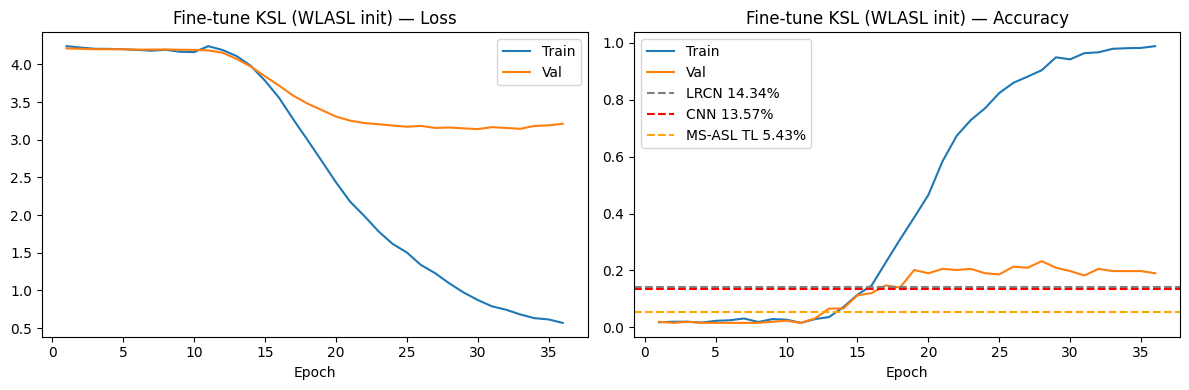

Figure saved: results/figures/05_finetune_curves.png


In [10]:
# ── Full fine-tune: unfreeze VGG layers 24+ ──────────────────────────
print(f'\n-- Full fine-tune ({FINETUNE_EPOCHS} epochs): unfreeze VGG 24+ --')

for i, layer in enumerate(lrcn_model.features.children()):
    if i >= 24:
        for p in layer.parameters():
            p.requires_grad = True

optimizer_ft = torch.optim.Adam([
    {'params': lrcn_model.features.parameters(),   'lr': LR_BACKBONE},
    {'params': lrcn_model.frame_fc.parameters(),   'lr': LR_LSTM},
    {'params': lrcn_model.lstm.parameters(),       'lr': LR_LSTM},
    {'params': lrcn_model.classifier.parameters(), 'lr': LR_HEAD},
], weight_decay=1e-4)

scheduler_ft = torch.optim.lr_scheduler.StepLR(
    optimizer_ft, step_size=10, gamma=0.5)

best_ksl_acc = 0
patience_cnt = 0
finetune_log = []

for epoch in range(1, FINETUNE_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(lrcn_model, ksl_train_loader,
                                optimizer_ft, criterion, training=True)
    vl_loss, vl_acc = run_epoch(lrcn_model, ksl_val_loader,
                                optimizer_ft, criterion, training=False)
    scheduler_ft.step()
    finetune_log.append([epoch, tr_loss, tr_acc, vl_loss, vl_acc])

    if vl_acc > best_ksl_acc:
        best_ksl_acc = vl_acc
        patience_cnt = 0
        torch.save(lrcn_model.state_dict(), CKPT_FINETUNE)
        marker = ' ✓'
    else:
        patience_cnt += 1
        marker = ''

    print(f'Ep {epoch:02d} | train {tr_acc:.2%} | val {vl_acc:.2%}{marker}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

full_log = warmup_log + [[r[0]+WARMUP_EPOCHS]+r[1:] for r in finetune_log]
save_log(str(LOGS_DIR / '05_finetune_ksl_log.csv'), full_log)
plot_curves(full_log, 'Fine-tune KSL (WLASL init)',
            str(FIGS_DIR / '05_finetune_curves.png'))

# Summary

In [11]:
LRCN_BASELINE = 0.1434
CNN_BASELINE  = 0.1357
MSASL_TL_V1   = 0.1008
MSASL_TL_V2   = 0.0543

print('='*52)
print('  TRANSFER LEARNING (WLASL) COMPLETE')
print('='*52)
print(f'  WLASL pretrain val acc  : {best_pretrain_acc:.2%}')
print(f'  Best KSL val acc        : {best_ksl_acc:.2%}')
print(f'  ---')
print(f'  CNN baseline            : {CNN_BASELINE:.2%}')
print(f'  LRCN baseline           : {LRCN_BASELINE:.2%}')
print(f'  MS-ASL TL v1            : {MSASL_TL_V1:.2%}')
print(f'  MS-ASL TL v2            : {MSASL_TL_V2:.2%}')
print(f'  Delta vs LRCN           : {best_ksl_acc - LRCN_BASELINE:+.2%}')
print(f'  Delta vs MS-ASL TL v2   : {best_ksl_acc - MSASL_TL_V2:+.2%}')
print('='*52)
print(f'  Checkpoint: {CKPT_FINETUNE}')
print()
print('  --> Update TRANSFER_NB05_WLASL in nb06 with this result')

  TRANSFER LEARNING (WLASL) COMPLETE
  WLASL pretrain val acc  : 13.94%
  Best KSL val acc        : 23.26%
  ---
  CNN baseline            : 13.57%
  LRCN baseline           : 14.34%
  MS-ASL TL v1            : 10.08%
  MS-ASL TL v2            : 5.43%
  Delta vs LRCN           : +8.92%
  Delta vs MS-ASL TL v2   : +17.83%
  Checkpoint: models/checkpoints/lrcn_transfer_ksl_wlasl_fast.pth

  --> Update TRANSFER_NB05_WLASL in nb06 with this result
